<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day11_practice3_%EA%B2%B0%EA%B3%BC_%EB%B0%B0%EC%B9%98_WnB%ED%8C%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install -U wandb

In [8]:
import os
os.environ["WANDB_MODE"] = "online"
import wandb
print("WANDB_MODE =", os.environ.get("WANDB_MODE"))

WANDB_MODE = online


In [9]:
# 로그인 (방법 B: Colab Secrets - 권장 방법)
import os
from google.colab import userdata
os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
import wandb
wandb.login()

True

In [10]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 9.1 MB/s eta 0:00:00


In [11]:
import os, glob
import pandas as pd
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [12]:
# 실전 학습 - 공개 도로 데이터셋으로 진짜 best.pt 만들기

# 전체 파이프라인 (colab GPU 필요)
# RDD2022(일본) 도로 데이터셋 다운로드 (클래스 포트홀, 균열)
# 라벨 PascalVOC XML → YOLO 형식 변환 (TXT)
# data.yaml 생성 → 학습 → best.pt

In [13]:
# 실전 1. RDD2022 다운로드 (FigShare, 전체 12.6GB - 일본 데이터만 사용)
import os, json, zipfile, urllib.request

RAW_DIR = "rdd2022_raw"
COUNTRY_NAME = "Japan"
FIGSHARE_ARTICLE_ID = 21431547    # RDD2022 전체 아티클
os.makedirs(RAW_DIR, exist_ok=True)

def _get_figshare_zip_url(article_id):    # 아티클에 첨부된 파일 목록 중 zip 파일의 다운로드 정보(url, 파일명, 용량)를 추출
  req = urllib.request.Request(f"https://api.figshare.com/v2/articles/{article_id}",headers={"User-Agent": "Mozilla/5.0"})
  with urllib.request.urlopen(req) as resp:   # urlopen(req) 요청 보내고
    meta = json.loads(resp.read().decode())   # resp.read() 응답 json문자열 → 파이썬 딕셔너리 객체로 변환
  zf = next((f for f in meta.get("files", []) if f ["name"].lower().endswith(".zip")), None)
  if zf is None:
    raise RuntimeError("아티클에서 zip 파일을 찾지 못했습니다")
  return zf["download_url"], zf["name"], zf["size"]

def _download(url, dest):   # url로 파일을 1MB 단위 청크로 나누어 다운로드하고 실시간 진행률%과 용량 MB을 출력
  req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
  with urllib.request.urlopen(req) as resp:
    total = int(resp.headers.get("Content-Length", 0)); done = 0    # Content-Length : 전체 파일 크기
    with open(dest, "wb") as f:
      while True:
        chunk = resp.read(1024 * 1024)    # 청크 단위 : 1MB로 파일 읽어온다
        if not chunk: break
        f.write(chunk); done += len(chunk)    # 가져온 조각을 파일에 쓴다
        if total:
          print(f"{done*100//total}% ({done//(1024*1024)}MB/{total//(1024*1024)}MB)",end="", flush=True)
    print()

def _find_inner_zip(raw_dir, country):    # raw_dir와 하위 폴더 전체를 탐색해서 국가명과 일치하는 zip 파일의 경로를 찾는다
  for root, _, files in os.walk(raw_dir):   # os.walk: raw_dir와 하위 폴더 전체를 탐색
    for fn in files:
      if fn.lower() == f"{country.lower()}.zip":    # japan.zip 찾기
        return os.path.join(root, fn)   # (절대경로, 상대경로) 반환
  return None

# 1. 전체 zip
zip_url, zip_name, zip_size = _get_figshare_zip_url(FIGSHARE_ARTICLE_ID)
zip_path = os.path.join(RAW_DIR, zip_name)
if os.path.isfile(zip_path):
  print(f"이미 다운로드됨: {zip_path}")
else:
  print(f"다운로드 중: {zip_name} ({zip_size//(1024*1024)}MB, 오래 걸립니다)")
  _download(zip_url, zip_path)

# 2. 1차 해제
inner = _find_inner_zip(RAW_DIR, COUNTRY_NAME)
if inner is None:
  print(f"1차 압축 해제: {zip_path}")
  with zipfile.ZipFile(zip_path) as zf: zf.extractall(RAW_DIR)
  inner = _find_inner_zip(RAW_DIR, COUNTRY_NAME)
assert inner is not None, f"{COUNTRY_NAME}.zip을 못 찾음 - rdd2022_raw/RDD2022/ 확인"

# 3. 2차 해제 - japan.zip
target = os.path.join(RAW_DIR, COUNTRY_NAME, "train", "images")
if os.path.isdir(target):
  print(f"이미 압축 해제됨: {target}")
else:
  print(f"2차 압축 해제: {inner}")
  with zipfile.ZipFile(inner) as zf: zf.extractall(RAW_DIR)
print(f"준비 완료: {target}")

다운로드 중: RDD2022_released_through_CRDDC2022.zip (12649MB, 오래 걸립니다)
0% (1MB/12649MB)0% (2MB/12649MB)0% (3MB/12649MB)0% (4MB/12649MB)0% (5MB/12649MB)0% (6MB/12649MB)0% (7MB/12649MB)0% (8MB/12649MB)0% (9MB/12649MB)0% (10MB/12649MB)0% (11MB/12649MB)0% (12MB/12649MB)0% (13MB/12649MB)0% (14MB/12649MB)0% (15MB/12649MB)0% (16MB/12649MB)0% (17MB/12649MB)0% (18MB/12649MB)0% (19MB/12649MB)0% (20MB/12649MB)0% (21MB/12649MB)0% (22MB/12649MB)0% (23MB/12649MB)0% (24MB/12649MB)0% (25MB/12649MB)0% (26MB/12649MB)0% (27MB/12649MB)0% (28MB/12649MB)0% (29MB/12649MB)0% (30MB/12649MB)0% (31MB/12649MB)0% (32MB/12649MB)0% (33MB/12649MB)0% (34MB/12649MB)0% (35MB/12649MB)0% (36MB/12649MB)0% (37MB/12649MB)0% (38MB/12649MB)0% (39MB/12649MB)0% (40MB/12649MB)0% (41MB/12649MB)0% (42MB/12649MB)0% (43MB/12649MB)0% (44MB/12649MB)0% (45MB/12649MB)0% (46MB/12649MB)0% (47MB/12649MB)0% (48MB/12649MB)0% (49MB/12649MB)0% (50MB/12649MB)0% (51MB/12649MB)0% (52MB/12649MB)0% (53MB/12649MB)0% (54MB/12649MB)0% (55MB/12649MB)0% (56MB

In [22]:
# 셀 2. PascalVOC XML → YOLO 형식 변환(TXT) + data.yaml 생성
import os
import random
import shutil
import xml.etree.ElementTree as ET

OUT_DIR, VAL_RATIO, SEED = "yolo_dataset", 0.2, 42

CLASS_MAP = {"D00": "crack", "D10": "crack", "D20": "crack", "D40": "pothole"}
FINAL_CLASSES = ["pothole", "crack"]
CLASS_TO_ID = {n: i for i, n in enumerate(FINAL_CLASSES)} #{"pothole":0, "crack":1}

def find_country_dirs(raw): # 압축 푼 폴더에서 (이미지폴더, 라벨폴더) 쌍들을 찾는다
  found=[]
  for root, _, _ in os.walk(raw): # 하위 전체 순회, root/하위폴더/파일들
    if os.path.basename(root) == "images" and "train" in root: # 폴더 이름이 정확히 "images"이고 경로에 "train"이 들어간 곳만
      parent = os.path.dirname(root) # images의 부모 폴더 (train 폴더)
      ann = next((c for c in [os.path.join(parent, "annotations", "xmls"), # 라벨 폴더 이름이 버전마다 다름. 실제로 존재하는 첫 번째를 택함
                              os.path.join(parent, "annotations"),
                              os.path.join(parent, "Annotations")]
                  if os.path.isdir(c)),None)
      if ann:
        found.append((root, ann)) # (이미지폴더, 라벨폴더) 튜플
      return found

def parse_voc(xp): # XML 한 개(xp)를 읽어 TXT 내용 형식으로 넣을 값을 반환 (이름, xmin, ymin, xmax, ymax, 이미지W, 이미지H)
  r = ET.parse(xp).getroot() # XML 파일 파싱, 최상위(root) 요소
  s = r.find("size") # <size> 태그 찾기 (이미지 가로ㆍ세로)
  W,H = int(s.findtext("width")), int(s.findtext("height"))
  out = []
  for o in r.findall("object"):
    b = o.find("bndbox")
    name = o.findtext("name")
    if name is None or b is None:
      continue
    try: out.append((name, float(b.findtext("xmin")), float(b.findtext("ymin")),
                     float(b.findtext("xmax")), float(b.findtext("ymax")), W,H))
    except (TypeError, ValueError):
      continue
  return out

def to_yolo(cid, xmin, ymin, xmax, ymax, W, H):
  clamp = lambda v: max(0.0, min(1.0, v))
  return(f"{cid} {clamp((xmax + xmin) / 2 / W):.6f} {clamp((ymin+ymax) / 2 / H):.6f} "
         f"{clamp((xmax-xmin)/W):.6f} {clamp((ymax-ymin)/H):.6f}")

pairs = find_country_dirs("rdd2022_raw")
assert pairs, "(이미지, 라벨) 폴더 쌍 목록을 못 찾음"
print(f"발견된 train 폴더: {len(pairs)}개")

tmp_i, tmp_l = os.path.join(OUT_DIR, "_ti"), os.path.join(OUT_DIR, "_tl")
os.makedirs(tmp_i, exist_ok=True)
os.makedirs(tmp_l, exist_ok=True)
stats = {"conv": 0, "no_target": 0, "no_xml": 0}

for img_dir, ann_dir in pairs:
  for fn in sorted(os.listdir(img_dir)):
    if not fn.lower().endswith((".jpg", ".jpeg", ".png")):
      continue
    base = os.path.splitext(fn)[0]
    xp = os.path.join(ann_dir, base + ".xml")
    if not os.path.isfile(xp):
      stats["no_xml"] += 1
      continue

    lines = [to_yolo(CLASS_TO_ID[CLASS_MAP[n]], *rest)for n, *rest in parse_voc(xp) if n in CLASS_MAP] # 관심 클래스(포트홀ㆍ균열)만 남김
    # parse_voc(xp) → (이름, xmin, ymin, xmax, ymax, 이미지W, 이미지H), to_yolo() → [cid, cx, cy, w, h]
    if not lines: # 이 이미지에 관심 물체가 하나도 없으면
      stats["no_target"] += 1
      continue
    shutil.copy2(os.path.join(img_dir, fn), os.path.join(tmp_i, base + ".jpg")) # 이미지 복사
    open(os.path.join(tmp_l, base + ".txt"),"w").write("\n".join(lines) + "\n") # 라벨 txt 쓰기
    stats["conv"] += 1

print(f"변환: {stats["conv"]}장 관심 클래스 없음{stats["no_target"]} XML없음 {stats["no_xml"]}")
assert stats["conv"] > 0, "변환된 이미지 0장"

발견된 train 폴더: 1개
변환: 7900장 관심 클래스 없음2606 XML없음 0


In [23]:
# train/val 분할
random.seed(SEED)
bases = sorted(os.path.splitext(f)[0] for f in os.listdir(tmp_i))
random.shuffle(bases) # 확장자면 이름 목록 만들고 무작위 섞기
n_val = max(1, int(len(bases) * VAL_RATIO))
val = set(bases[:n_val]) # 앞 n_val개를 검증셋으로
for sp in ("train", "val"):
  os.makedirs(os.path.join(OUT_DIR, "images", sp), exist_ok=True)
  os.makedirs(os.path.join(OUT_DIR, "labels", sp), exist_ok=True)
for base in bases:
  sp = "val" if base in val else "train"
  shutil.move(os.path.join(tmp_i, base + ".jpg"), os.path.join(OUT_DIR, "images", sp, base + ".jpg")) # 임시 폴더 → 최종 폴더로 이동
  shutil.move(os.path.join(tmp_l, base + ".txt"), os.path.join(OUT_DIR, "labels", sp, base + ".txt")) # 이미지ㆍ라벨을 짝 맞춰
shutil.rmtree(tmp_i, ignore_errors=True)
shutil.rmtree(tmp_l, ignore_errors=True) # 임시 폴더 삭제
print(f"분할: train {len(bases)-n_val}장 / val {n_val}장")

분할: train 6320장 / val 1580장


In [24]:
# data.yaml - 학습의 주문서
with open(os.path.join(OUT_DIR, "data.yaml"), "w", encoding="utf-8") as f:
  f.write(f"path: {os.path.abspath(OUT_DIR)}\n")
  f.write("train: images/train\nval:images/val\n")
  f.write(f"nc: {len(FINAL_CLASSES)}\n names: {FINAL_CLASSES}\n")
print(f"data.yaml 생성 - names={FINAL_CLASSES} (이게 CLASS_MAP의 키)")

data.yaml 생성 - names=['pothole', 'crack'] (이게 CLASS_MAP의 키)


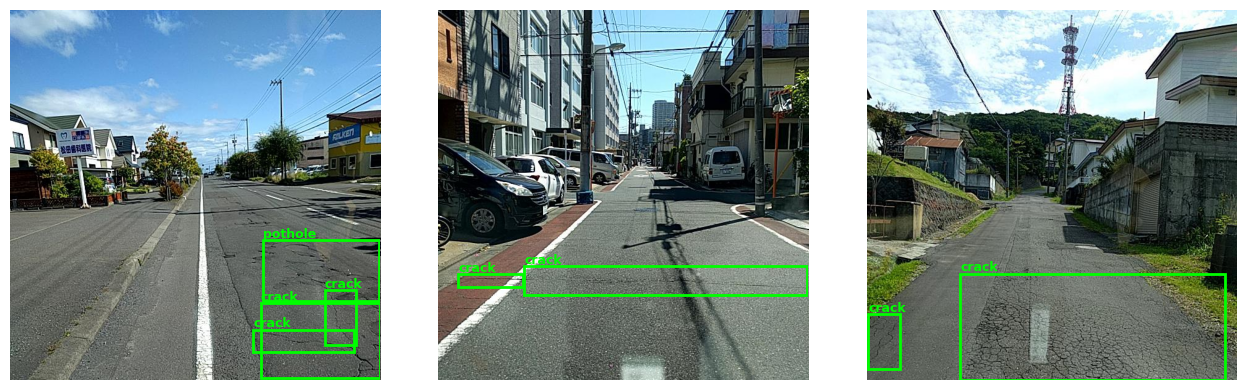

박스가 실제 파손 부위를 감싸는지 눈으로 확인 (안 맞으면 변환 로직 점검)


In [26]:
# 실전 2.5 라벨 시각화 검증 - 학습 전 반드시
# 잘못 변환된 라벨로 학습하면 GPU를 몇 시간 태운다. 3장만 눈으로 확인
import glob, matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image

_names = ["pothole", "crack"]
_imgs = sorted(glob.glob("yolo_dataset/images/train/*.jpg"))[:3]
fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax, ip in zip(axes, _imgs):
  img = Image.open(ip)
  W, H = img.size
  ax.imshow(img)
  ax.axis("off")
  Ip = ip.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
  if os.path.exists(Ip):
    for line in open(Ip):
      cls, cx, cy, w, h = map(float, line.split())
      x1, y1 = (cx - w/2) * W, (cy - h/2) * H
      ax.add_patch(patches.Rectangle((x1, y1), w*W, h*H, fill=False,color="lime", lw=2))
      ax.text(x1, y1-4, _names[int(cls)], color="lime", fontsize=9, weight="bold")
plt.tight_layout(); plt.savefig("plot_rdd_labels.png"); plt.show()
print("박스가 실제 파손 부위를 감싸는지 눈으로 확인 (안 맞으면 변환 로직 점검)")

In [ ]:
# 실전 3. YOLO 학습 - best.pt를 만든다 (전이학습 + W&B 팀 로깅)
from ultralytics import YOLO, settings
# W&B 팀 설정
TEAM = "" # 팀 이름
PROJECT_NAME = "road-detect"
RUN_NAME = "kim_b16_e100" # 이름 규칙: 이름_데이터_에폭, 이름_배치_에폭

if TEAM:
  settings.update({"wandb":True})
  project = f"{TEAM}/{PROJECT_NAME}"
  print(f"W&B 팀 로깅 ON - {project}/{RUN_NAME}")
else:
  settings.update({"wandb":False})
  project, RUN_NAME = "runs", "road_hazard"
  print("팀 미설정 → 로컬 runs/에 저장")

model = YOLO("yolo11n.pt")
results = model.train(
    data = "yolo_dataset/data.yaml",
    epochs = 100,
    imgsz = 640,
    batch = 16,
    patience = 20,
    project = project, name = RUN_NAME, exist_ok=True,
)
print("학습 완료 - best.pt:", results.save_dir)

In [ ]:
# 셀 1. results.csv - 에폿별 성적표 읽기
csv_candidates = glob.glob("**/coco8_test*/results.csv", recursive=True)
run_dir = os.path.dirname(sorted(csv_candidates)[-1])
print("결과 폴더:", run_dir)

In [ ]:
# 셀 2. best.pt로 추론 - 우리가 만든 모델 사용하기
best_path = os.path.join(run_dir, "weights", "best.pt")
model = YOLO(best_path)

In [ ]:
# 감지 결과 이미지 출력
def show(r, title=""):
  plt.figure(figsize=(5, 6))
  plt.imshow(r.plot()[:, :, ::-1])  # r.plot()=  BGR -> RGB 로 뒤집기
  plt.axis("off")
  if title:
    plt.title(title)
  plt.show()

In [ ]:
r = model("crack2.png", verbose=False)[0]
name = [r.names[int(b.cls)] for b in r.boxes]
show(r, f"{name}  (감지 {len(r.boxes)}개)")